In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe                     # package for regridding 
#import cartopy.crs as ccrs              # for the regridding test(now only to understand how it works later maybe more - probably I can do a lot with this package

#import gravity toolkit 
import gravity_toolkit as gravtk

#from scipy import signal              #not sure if I need those
#import importlib

import Kyrafunctions as ky

import sys
sys.path.append('../code')


import SeaLevelContrib as slc

In [2]:
data_path = '../data/GravIs/'
output_path = '../outputs/Antarcticatest/'
output_path2 = '../outputs/Gravis_Antarctica/'

<xarray.Dataset> Size: 523kB
Dimensions:   (lat: 180, lon: 360)
Coordinates:
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    mask      (lat, lon) float32 259kB nan nan nan nan nan ... 1.0 1.0 1.0 1.0
    mask_med  (lat, lon) float32 259kB ...
Attributes:
    source_file:    This NetCDF file was built from the script ExtractReferen...
    creation_date:  2020-08-05 16:30

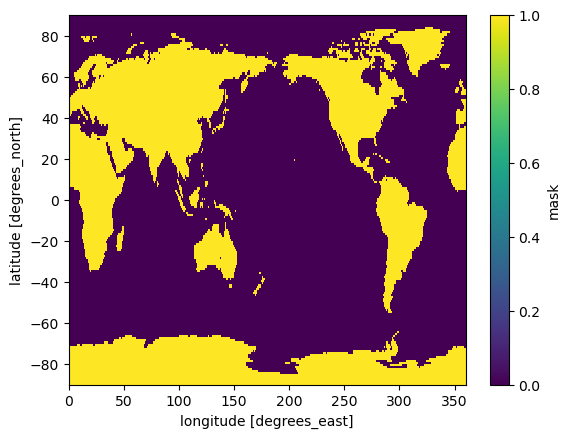

In [3]:
# Define the reference mask: 

path_masks = '/Users/kyrab/Github/SLBudget/data/Masks/'
masks_ds = xr.open_dataset(f'{path_masks}reference_masks.nc')

landsea = xr.where(masks_ds.mask==1, 0, 1)
landsea.plot()
#print(masks_ds['lat'].values)

#landsea

display(masks_ds)

Number of peninsula pixels: 16


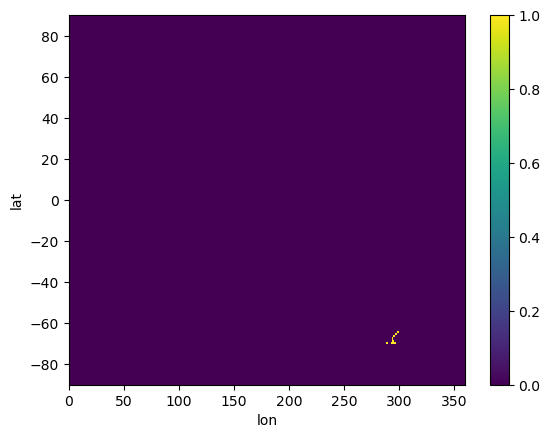

In [13]:
import numpy as np
import xarray as xr

# Get lat/lon
lat = landsea['lat'].values
lon = landsea['lon'].values

# Ensure latitude is ascending
if lat[0] > lat[-1]:
    lat = lat[::-1]
    landsea = landsea.sel(lat=lat)

# Correct Antarctic Peninsula bounds
lat_bounds = [-70, -6 v     ]
lon_bounds = [285, 300]   # if lon in 0-360

# Create 2D grids
lon2d, lat2d = np.meshgrid(lon, lat)

# Boolean mask for rectangle
peninsula_box = (lat2d >= lat_bounds[0]) & (lat2d <= lat_bounds[1]) & \
                (lon2d >= lon_bounds[0]) & (lon2d <= lon_bounds[1])

# Intersection with land mask
peninsula_mask = np.zeros_like(landsea.values)
peninsula_mask[peninsula_box & (landsea.values == 1)] = 1

# Convert to xarray DataArray
peninsula_mask_da = xr.DataArray(
    peninsula_mask,
    coords={'lat': lat, 'lon': lon},
    dims=('lat', 'lon')
)

# Check if mask has values
print("Number of peninsula pixels:", np.sum(peninsula_mask_da.values))


peninsula_mask_da.plot()